In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import gradio as gr
from tensorflow.keras.layers import Dense, Dropout, MultiHeadAttention, LayerNormalization
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from prettytable import PrettyTable
from xgboost import XGBClassifier
from joblib import dump, load
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [6]:
df=pd.read_csv("/kaggle/input/group-project-comp4432/kaggle1/HTRU_2.csv")
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [7]:
df.columns=['mean_profile','std_profile','kurtosis_profile','skewness_profile','mean_dmsc','std_dmsc','kurtosis_dmsc','skewness_dmsc','target']

In [8]:
df.isna().sum()

mean_profile        0
std_profile         0
kurtosis_profile    0
skewness_profile    0
mean_dmsc           0
std_dmsc            0
kurtosis_dmsc       0
skewness_dmsc       0
target              0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean_profile      17897 non-null  float64
 1   std_profile       17897 non-null  float64
 2   kurtosis_profile  17897 non-null  float64
 3   skewness_profile  17897 non-null  float64
 4   mean_dmsc         17897 non-null  float64
 5   std_dmsc          17897 non-null  float64
 6   kurtosis_dmsc     17897 non-null  float64
 7   skewness_dmsc     17897 non-null  float64
 8   target            17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [10]:
df.describe

<bound method NDFrame.describe of        mean_profile  std_profile  kurtosis_profile  skewness_profile  \
0        102.507812    58.882430          0.465318         -0.515088   
1        103.015625    39.341649          0.323328          1.051164   
2        136.750000    57.178449         -0.068415         -0.636238   
3         88.726562    40.672225          0.600866          1.123492   
4         93.570312    46.698114          0.531905          0.416721   
...             ...          ...               ...               ...   
17892    136.429688    59.847421         -0.187846         -0.738123   
17893    122.554688    49.485605          0.127978          0.323061   
17894    119.335938    59.935939          0.159363         -0.743025   
17895    114.507812    53.902400          0.201161         -0.024789   
17896     57.062500    85.797340          1.406391          0.089520   

        mean_dmsc   std_dmsc  kurtosis_dmsc  skewness_dmsc  target  
0        1.677258  14.860146    

In [11]:
pulsar=df[df['target']==1]
pulsar_count=pulsar['target'].value_counts()[1]
non_pul=df[df['target']==0]
nonpul_count=non_pul['target'].value_counts()[0]

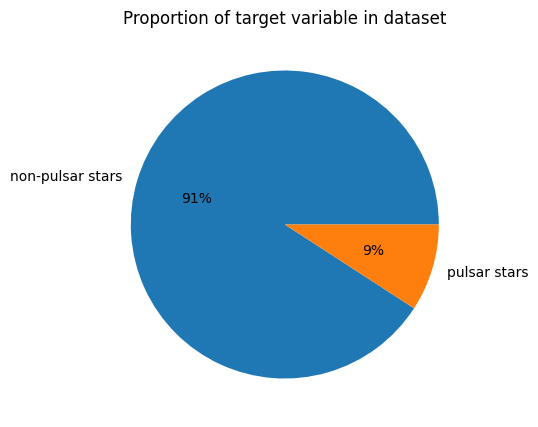

There are 1639 signals that belong to pulsar stars and 16258 signals that aren't from pulsars.


In [12]:
#pie plotting the stats between pulsars and not pulsars
plt.figure(figsize=(5,5))
plt.pie(df["target"].value_counts().values,labels=["non-pulsar stars","pulsar stars"], autopct="%1.0f%%")
plt.title("Proportion of target variable in dataset")
plt.show()
print("There are " + str(pulsar_count) + " signals that belong to pulsar stars "
      + "and " + str(nonpul_count) + " signals that aren't from pulsars.")

<Axes: >

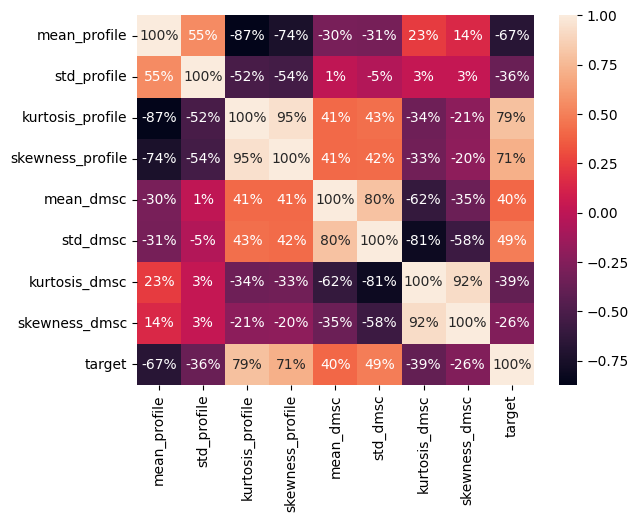

In [13]:
sns.heatmap(df.iloc[:,0:9].corr(),annot=True,fmt='.0%')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

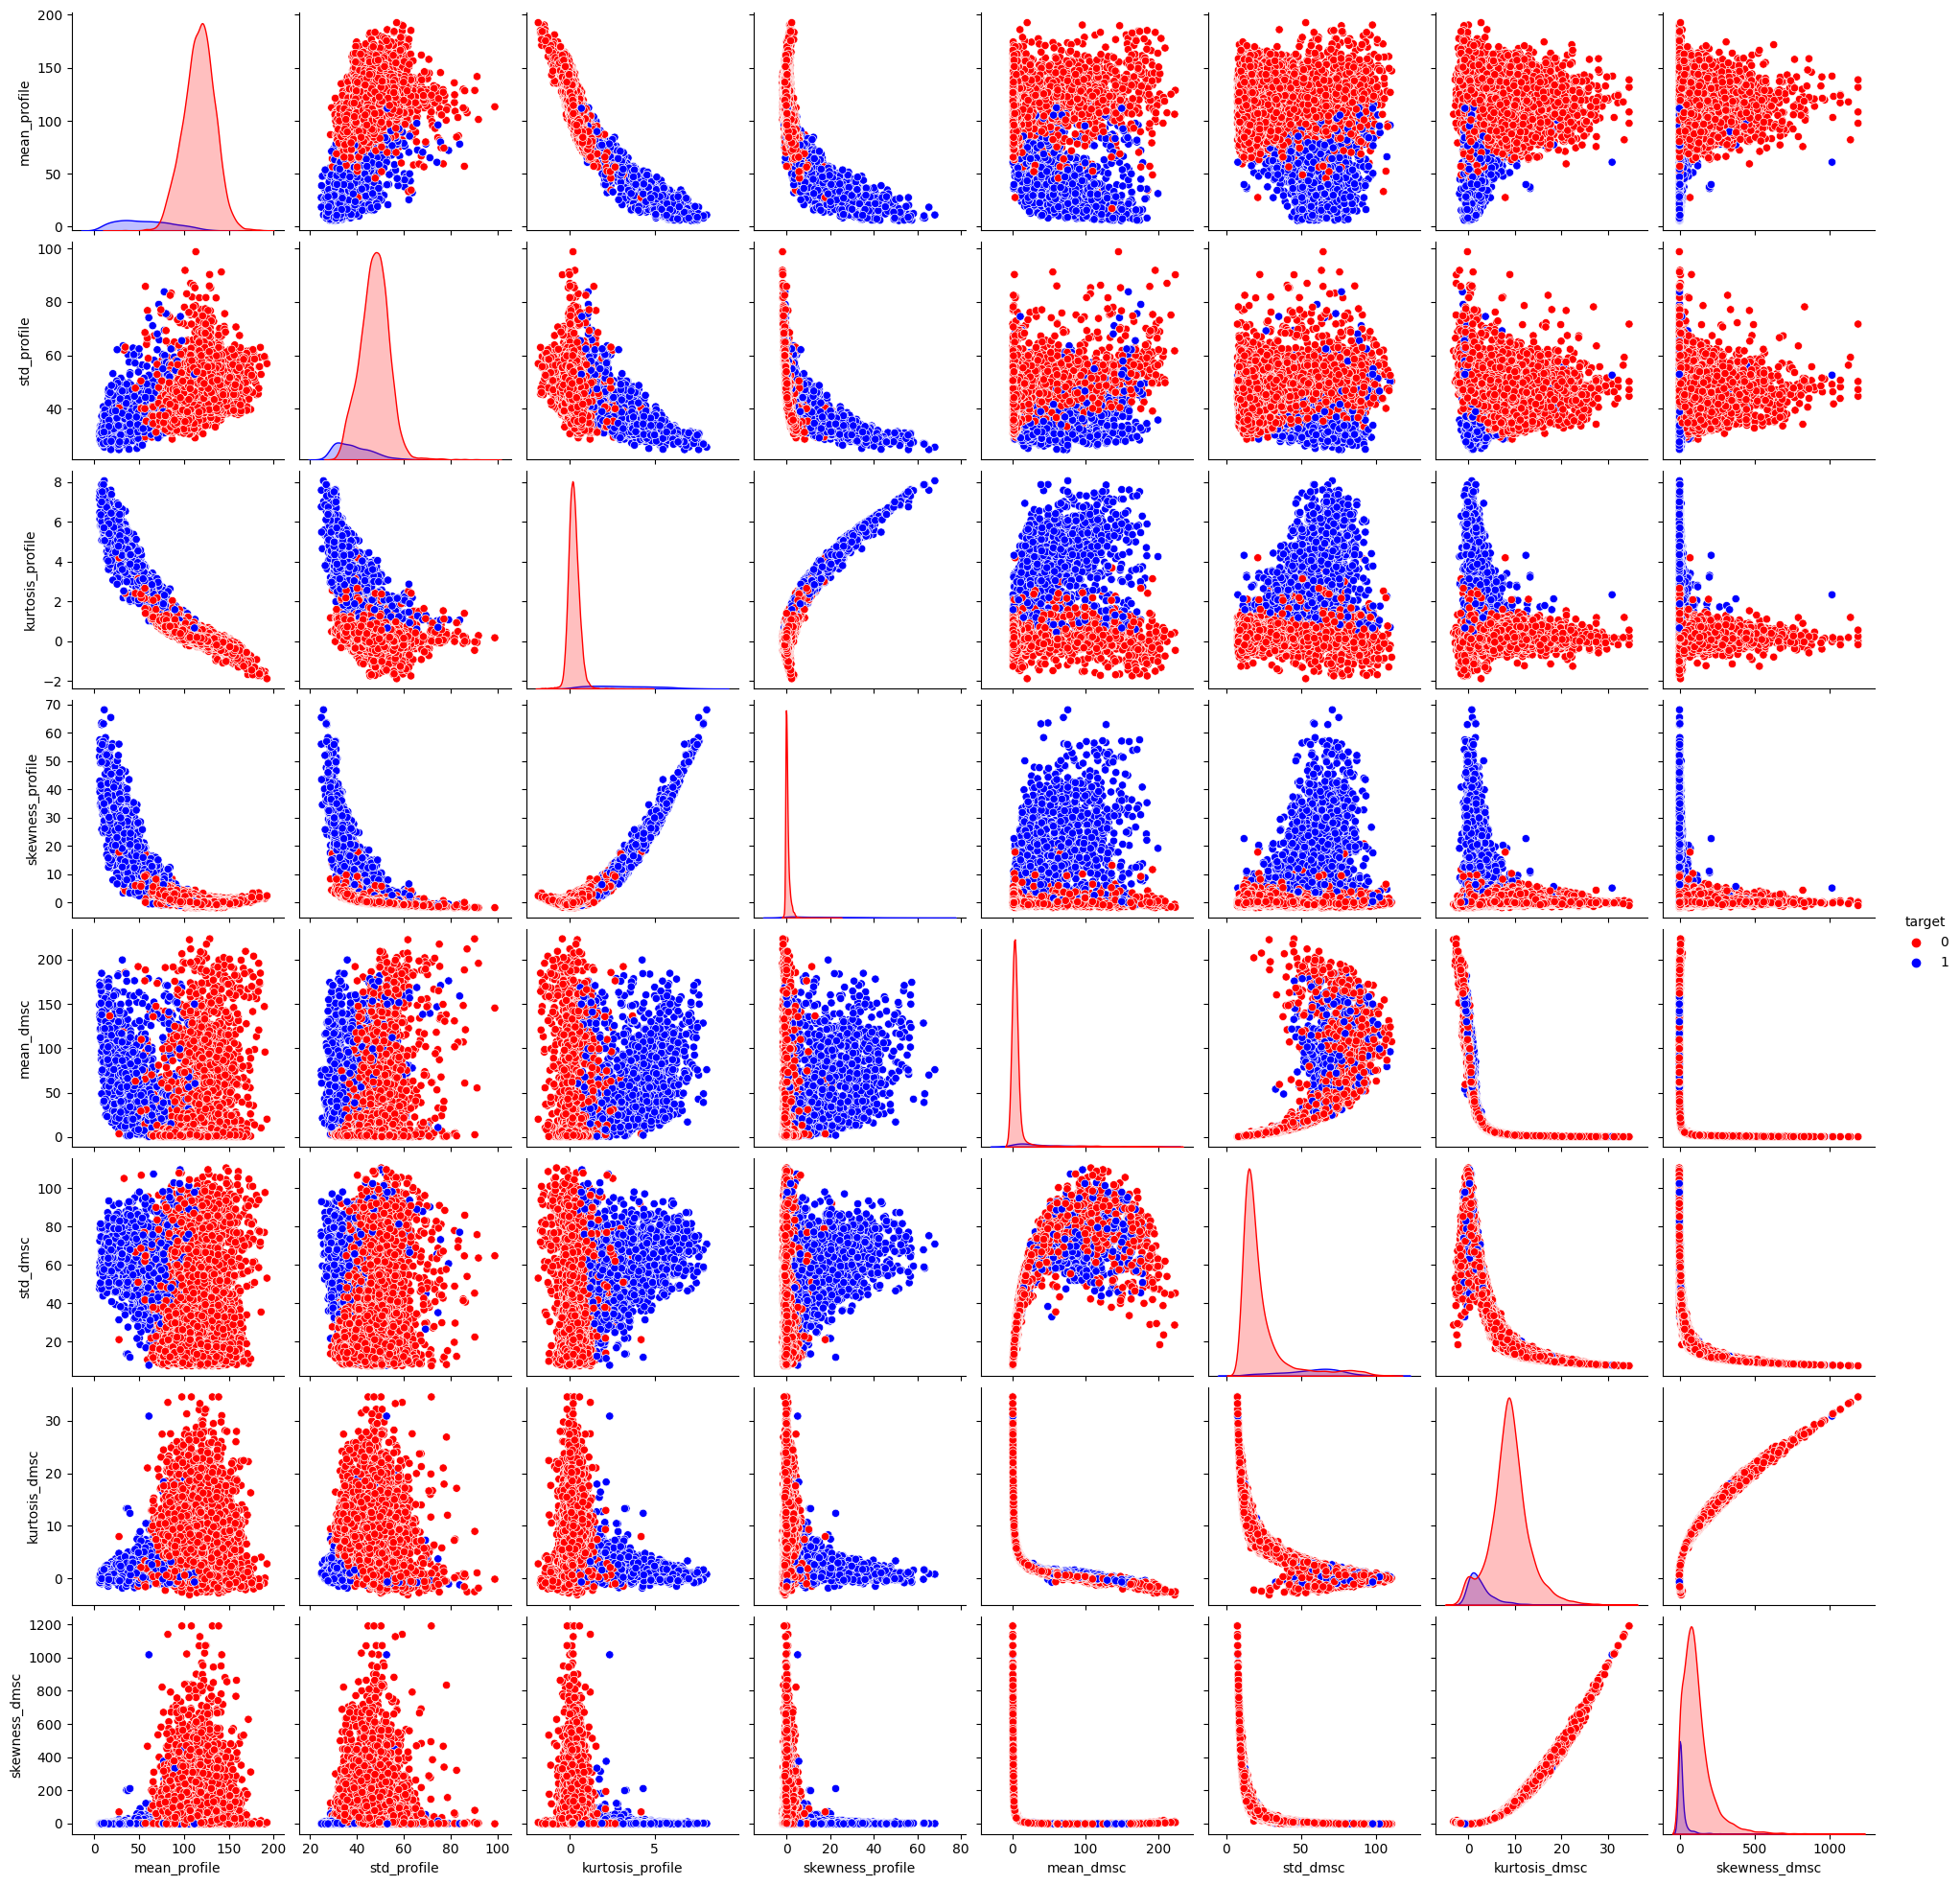

In [14]:
sns.pairplot(df,hue='target',palette=['red','blue'])

In [15]:
# Select first 8 columns as features (0-based indexing)
features = df.iloc[:, 0:8]  # 8 features
# Select 9th column (index 8) as target variable
target = df.iloc[:, 8]

# Initialize RobustScaler for outlier-resistant normalization
scaler = RobustScaler()
# Fit scaler to training data and transform features
X_scaled = scaler.fit_transform(features)

# Split dataset while preserving class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    target, 
    test_size=0.35,  # 35% data for testing
    stratify=target,  # Maintain original class ratios
    random_state=42  # Seed for reproducibility
)

In [16]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate=0.25):
    # Ensure correct key_dim calculation based on attention head configuration
    key_dim = head_size // num_heads
    
    # Multi-head self-attention mechanism
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        attention_axes=1
    )(inputs, inputs)
    
    # Regularization through stochastic depth
    attention_output = Dropout(dropout_rate)(attention_output)
    
    # Residual connection with layer normalization
    x = LayerNormalization(epsilon=1e-6)(attention_output + inputs)
    
    # Position-wise feed-forward network
    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dropout(dropout_rate)(ff_output)
    ff_output = Dense(inputs.shape[-1])(ff_output)  # Project back to original dimension
    
    # Final residual connection with normalization
    return LayerNormalization(epsilon=1e-6)(x + ff_output)

def build_improved_model():
    # Define model input tensor with 8 features
    inputs = tf.keras.Input(shape=(8,))
    
    # Feature projection layer with regularization
    x = Dense(16, activation='relu')(inputs)  # Reduce initial layer neurons to match reference code
    x = Dropout(0.25)(x)
    
    # Transformer encoder block with optimized parameters
    x = transformer_encoder(
        x, 
        head_size=16,    # Total dimension per attention head
        num_heads=4,     # Number of parallel attention mechanisms
        ff_dim=32,       # Reduced feed-forward dimension for efficiency
        dropout_rate=0.25
    )
    
    # Binary classification output layer
    outputs = Dense(1, activation="sigmoid")(x)
    
    # Instantiate Keras model
    model = tf.keras.Model(inputs, outputs)
    
    # Configure training parameters
    model.compile(
        optimizer='adam',         # Default Adam configuration per reference
        loss='binary_crossentropy',  # Cross-entropy for binary classification
        metrics=['accuracy']      # Track classification accuracy
    )
    return model

# Instantiate the optimized transformer model
model = build_improved_model()

I0000 00:00:1745314373.513597      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [17]:
# print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 8)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 16)             │            144 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 16)             │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 16)             │          1,088 │ dropout[0][0],         │
│ (MultiHeadAttention)      │                        │                │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 16)             │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 16)             │              0 │ dropout_2[0][0],       │
│                           │                        │                │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 16)             │             32 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 32)             │            544 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 32)             │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 16)             │            528 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 16)             │              0 │ layer_normalization[0… │
│                           │                        │                │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 16)             │             32 │ add_1[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1)              │             17 │ layer_normalization_1… │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,385 (9.32 KB)

 Trainable params: 2,385 (9.32 KB)

 Non-trainable params: 0 (0.00 B)

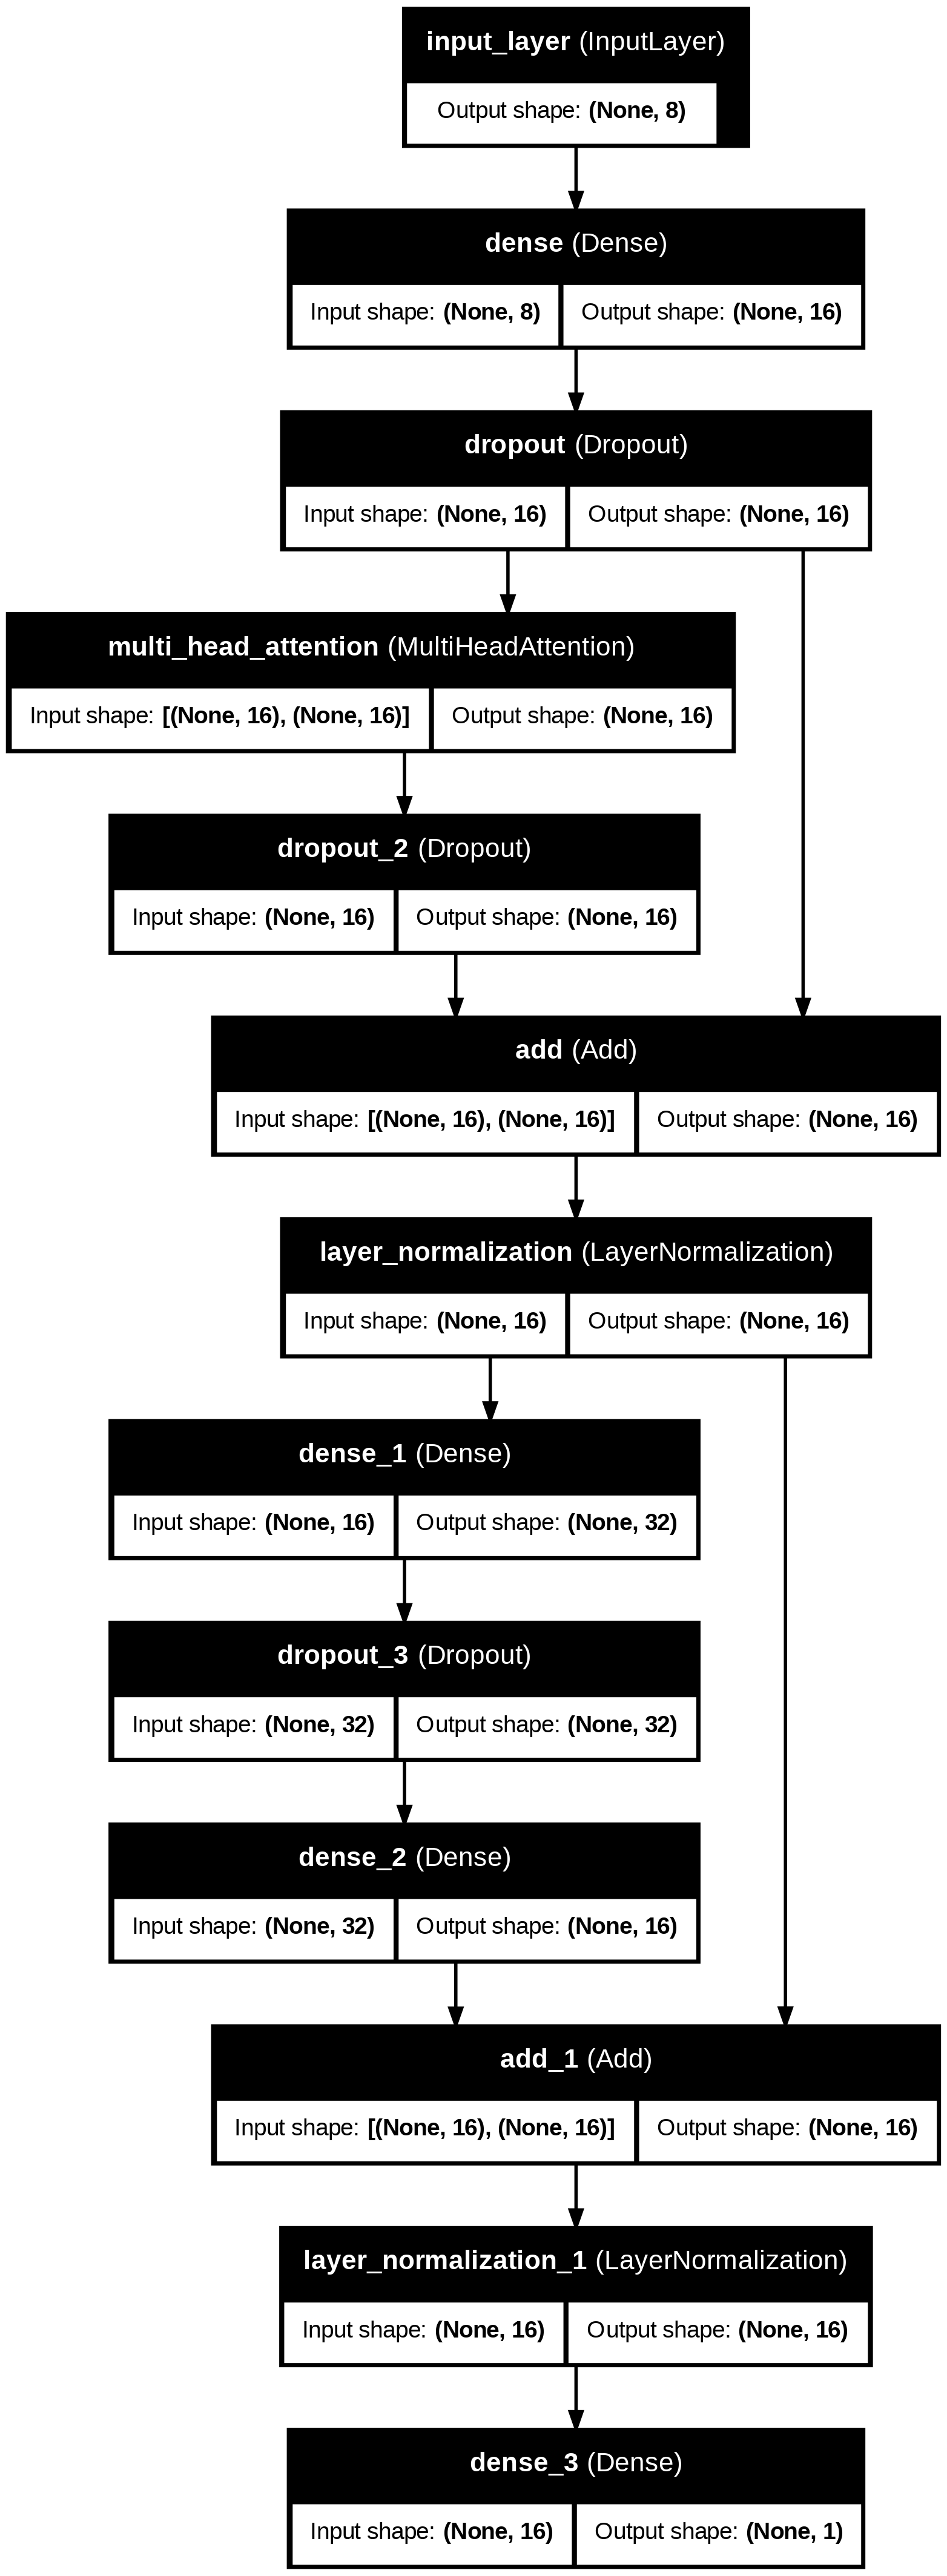

In [18]:
#Plot the model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [19]:
# Set the weight
weight = {0: 1., 1: 2.}

In [20]:
# --- turn y_train , y_test to NumPy array---
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [21]:
#Set the early_stopping for the model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model throuh model.fit
history = model.fit(
    X_train, y_train_np,  
    epochs=100,
    batch_size=64,
    class_weight=weight,
    validation_data=(X_test, y_test_np), 
    callbacks=[early_stopping],
    verbose=2
)


Epoch 1/100


I0000 00:00:1745314402.715122     111 service.cc:148] XLA service 0x7f6a60011af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745314402.715606     111 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745314403.249106     111 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745314405.773440     111 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


182/182 - 12s - 64ms/step - accuracy: 0.9191 - loss: 0.2783 - val_accuracy: 0.9757 - val_loss: 0.0863
Epoch 2/100
182/182 - 0s - 2ms/step - accuracy: 0.9686 - loss: 0.1582 - val_accuracy: 0.9780 - val_loss: 0.0796
Epoch 3/100
182/182 - 0s - 2ms/step - accuracy: 0.9696 - loss: 0.1518 - val_accuracy: 0.9794 - val_loss: 0.0775
Epoch 4/100
182/182 - 0s - 2ms/step - accuracy: 0.9737 - loss: 0.1409 - val_accuracy: 0.9804 - val_loss: 0.0769
Epoch 5/100
182/182 - 0s - 2ms/step - accuracy: 0.9746 - loss: 0.1329 - val_accuracy: 0.9786 - val_loss: 0.0807
Epoch 6/100
182/182 - 0s - 2ms/step - accuracy: 0.9752 - loss: 0.1320 - val_accuracy: 0.9799 - val_loss: 0.0752
Epoch 7/100
182/182 - 0s - 2ms/step - accuracy: 0.9746 - loss: 0.1315 - val_accuracy: 0.9805 - val_loss: 0.0739
Epoch 8/100
182/182 - 0s - 2ms/step - accuracy: 0.9749 - loss: 0.1273 - val_accuracy: 0.9792 - val_loss: 0.0771
Epoch 9/100
182/182 - 0s - 2ms/step - accuracy: 0.9746 - loss: 0.1307 - val_accuracy: 0.9807 - val_loss: 0.0722
Ep

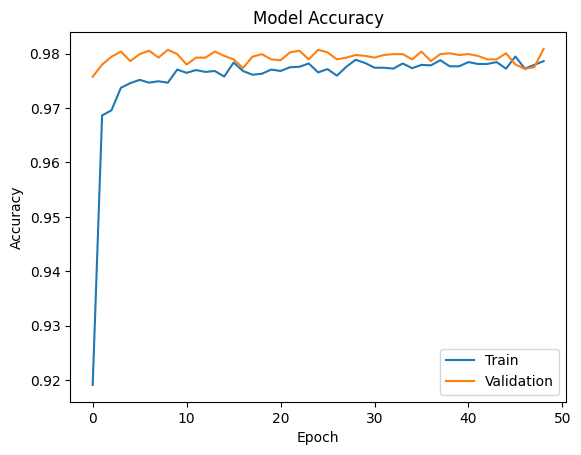

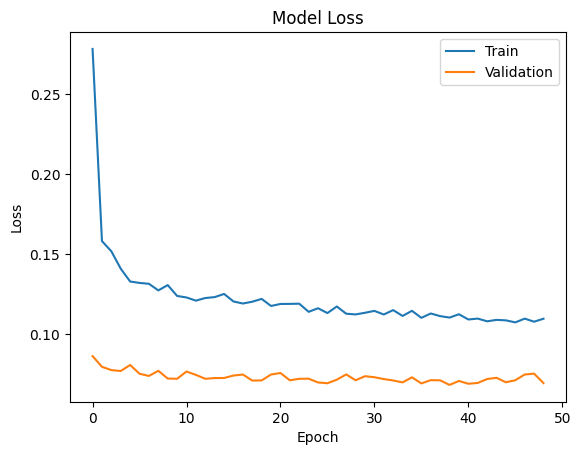

In [27]:
#Visualizing accuracy for both training and test data
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

#Visualizing loss for both training and test data
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


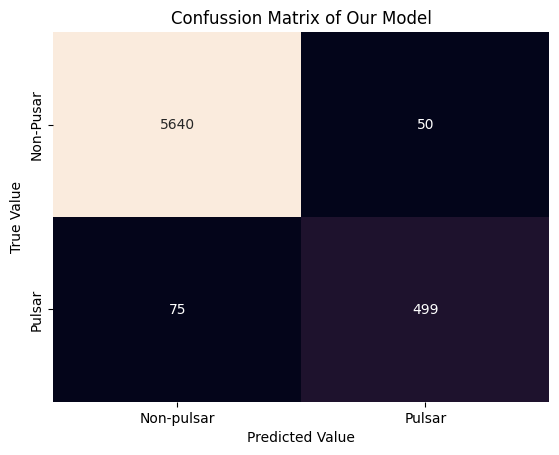

In [23]:
#Confussion Matrix
label_aux = plt.subplot()
prediction = model.predict(X_test)
cm = confusion_matrix(y_test, np.round(prediction))
cm_nn = pd.DataFrame(cm, index = ['Non-Pusar','Pulsar'], columns = ['Non-pulsar','Pulsar'])
sns.heatmap(cm_nn,annot=True,fmt="d", cbar=False)
label_aux.set_title("Confussion Matrix of Our Model")
label_aux.set_xlabel('Predicted Value');label_aux.set_ylabel('True Value');

In [24]:
#Printing some metrics
from prettytable import PrettyTable
ptbl = PrettyTable()
ptbl.field_names = ["Accuracy", "Recall", "F1Score"]
ptbl.add_row([accuracy_score(y_test,np.round(prediction)),recall_score(y_test, np.round(prediction)),
              f1_score(y_test, np.round(prediction))])
print(ptbl)

+-------------------+--------------------+--------------------+
|      Accuracy     |       Recall       |      F1Score       |
+-------------------+--------------------+--------------------+
| 0.980044699872286 | 0.8693379790940766 | 0.8886910062333037 |
+-------------------+--------------------+--------------------+


In [25]:
def predict(*features):
    # Convert input features to numpy array format
    features_array = list(features)
    # Apply feature scaling using pre-trained scaler
    scaled = scaler.transform([features_array])
    
    # Get prediction probability (class 1 confidence)
    prob = float(model.predict(scaled)[0][0])
    
    # Return prediction labels with probabilities
    return {"Non-Pulsar": 1-prob, "Pulsar": prob}

# Create Gradio web interface
demo = gr.Interface(
    fn=predict,
    # Create numerical input fields using dataset column names
    inputs=[gr.Number(label=col) for col in df.columns[:-1]],
    # Configure label output with confidence percentages
    outputs=gr.Label(label="Prediction Result"),
    title="Pulsar Identification System",
    description="Input eight feature values to predict if the celestial object is a pulsar",
    allow_flagging="never"  # Disable manual result flagging
)

# Launch the web application
demo.launch()

/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://4b5bf1f9ca97b0f502.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Non-pulsar example：
[102.507812, 58.882430, 0.465318, -0.515088, 1.677258, 14.860146, 10.576487, 127.393580]
Pulsar example：
[48.2421875, 36.49202526, 2.935560303, 10.88874578, 41.5041806, 62.89781076, 1.472488674, 1.305269046]   


--- Noise Sensitivity Analysis ---

Predicting with Noise Level (Std Dev): 0.0
+-------------------+--------------------+--------------------+
|      Accuracy     |       Recall       |      F1-Score      |
+-------------------+--------------------+--------------------+
| 0.980044699872286 | 0.8693379790940766 | 0.8886910062333037 |
+-------------------+--------------------+--------------------+

Predicting with Noise Level (Std Dev): 0.1
+--------------------+--------------------+-------------------+
|      Accuracy      |       Recall       |      F1-Score     |
+--------------------+--------------------+-------------------+
| 0.9802043422733078 | 0.8710801393728222 | 0.889679715302491 |
+--------------------+--------------------+-------------------+

Predicting with Noise Level (Std Dev): 0.2
+--------------------+-------------------+--------------------+
|      Accuracy      |       Recall      |      F1-Score      |
+--------------------+-------------------+--------------------+


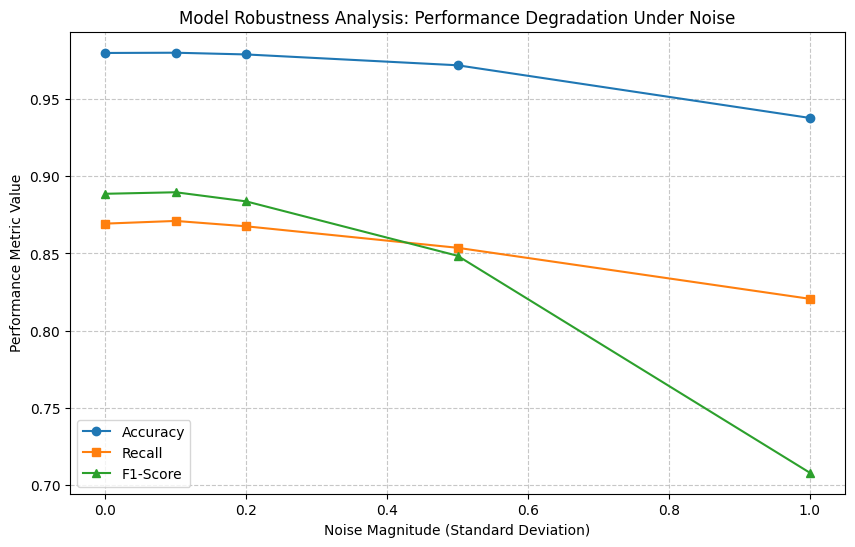

In [26]:
print("\n--- Noise Sensitivity Analysis ---")
# Define different noise standard deviation levels
noise_levels = [0.0, 0.1, 0.2, 0.5, 1.0]  
results_noise = {"Noise Level": [], "Accuracy": [], "Recall": [], "F1Score": []}

for std_dev in noise_levels:
    # Generate Gaussian noise with specified standard deviation
    # np.random.seed(42)  # Optional: Set seed for reproducible noise generation
    noise = np.random.normal(0, std_dev, X_test.shape)
    
    # Create noisy test data
    X_test_noisy = X_test + noise
    
    # Model prediction (requires re-running predictions)
    print(f"\nPredicting with Noise Level (Std Dev): {std_dev}")
    prediction_noisy = model.predict(X_test_noisy, verbose=0)  # Suppress progress bars
    prediction_noisy_rounded = np.round(prediction_noisy)
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, prediction_noisy_rounded)
    rec = recall_score(y_test, prediction_noisy_rounded)
    f1 = f1_score(y_test, prediction_noisy_rounded)
    
    # Store results
    results_noise["Noise Level"].append(std_dev)
    results_noise["Accuracy"].append(acc)
    results_noise["Recall"].append(rec)
    results_noise["F1Score"].append(f1)
    
    # Display formatted results table
    ptbl_noise = PrettyTable()
    ptbl_noise.field_names = ["Accuracy", "Recall", "F1-Score"]
    ptbl_noise.add_row([acc, rec, f1])
    print(ptbl_noise)

# Visualize noise impact on performance metrics
results_df_noise = pd.DataFrame(results_noise)
plt.figure(figsize=(10, 6))
plt.plot(results_df_noise["Noise Level"], results_df_noise["Accuracy"], 
         marker='o', label='Accuracy')
plt.plot(results_df_noise["Noise Level"], results_df_noise["Recall"], 
         marker='s', label='Recall')
plt.plot(results_df_noise["Noise Level"], results_df_noise["F1Score"], 
         marker='^', label='F1-Score')

plt.title('Model Robustness Analysis: Performance Degradation Under Noise')
plt.xlabel('Noise Magnitude (Standard Deviation)')
plt.ylabel('Performance Metric Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()